In [5]:
#importing the Libraies
import numpy as np
import pandas as pd

In [7]:
# Reading the Dataset
dataset = pd.read_csv('50_Startups.csv')

In [9]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [11]:
datasets=pd.get_dummies(dataset,drop_first=True)

In [13]:
datasets

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False
5,131876.90,99814.71,362861.36,156991.12,False,True
6,134615.46,147198.87,127716.82,156122.51,False,False
7,130298.13,145530.06,323876.68,155752.60,True,False
8,120542.52,148718.95,311613.29,152211.77,False,True
9,123334.88,108679.17,304981.62,149759.96,False,False


In [15]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [17]:
indep=datasets[['R&D Spend','Administration', 'Marketing Spend','State_Florida', 'State_New York']]
dep=datasets[['Profit']]

In [19]:
#split into training set and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(indep, dep, test_size = 1/3, random_state = 0)

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
param_grid={'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],'max_features': [None,'sqrt','log2'],'splitter':['best','random']}
grid=GridSearchCV(DecisionTreeRegressor(),param_grid,refit=True, verbose=3,n_jobs=-1)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse'],
                         'max_features': [None, 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             verbose=3)

In [45]:
grid.best_score_

0.854393868794368

In [47]:
re=grid.cv_results_
re

{'mean_fit_time': array([0.00403323, 0.00342956, 0.00400734, 0.00275435, 0.00498462,
        0.00331101, 0.00339031, 0.00387239, 0.00281792, 0.00512753,
        0.00327363, 0.00314741, 0.00306349, 0.00294967, 0.00266638,
        0.00322227, 0.00344725, 0.00292158]),
 'std_fit_time': array([2.61785771e-05, 2.76089491e-03, 1.27429511e-03, 7.33632101e-04,
        2.50657747e-03, 1.07583586e-03, 1.06059246e-03, 2.99218109e-04,
        7.66632535e-04, 1.49303998e-03, 9.64680163e-04, 9.45930385e-04,
        6.37295893e-04, 5.14423219e-04, 5.78578783e-04, 9.89701252e-04,
        1.35177163e-03, 5.88429766e-04]),
 'mean_score_time': array([0.00390363, 0.00375257, 0.00311718, 0.00456266, 0.00325384,
        0.0030777 , 0.00238929, 0.00427732, 0.00291014, 0.00352688,
        0.00251708, 0.00365109, 0.00274501, 0.00267882, 0.00312886,
        0.00343184, 0.0028337 , 0.00303535]),
 'std_score_time': array([0.00101675, 0.00149007, 0.00092228, 0.00081014, 0.00087767,
        0.00113575, 0.00082192, 

In [49]:
table=pd.DataFrame.from_dict(re)

In [51]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004033,0.000026,0.003904,0.001017,squared_error,None,best,"{'criterion': 'squared_error', 'max_features':...",0.804570,0.779565,0.920740,0.845248,0.921846,0.854394,0.058510,1
1,0.003430,0.002761,0.003753,0.001490,squared_error,None,random,"{'criterion': 'squared_error', 'max_features':...",0.513530,0.865722,0.932258,-1.100807,0.867532,0.415647,0.772382,9
2,0.004007,0.001274,0.003117,0.000922,squared_error,sqrt,best,"{'criterion': 'squared_error', 'max_features':...",0.576753,0.822564,0.928360,0.437005,0.920855,0.737108,0.196682,4
3,0.002754,0.000734,0.004563,0.000810,squared_error,sqrt,random,"{'criterion': 'squared_error', 'max_features':...",0.582894,-2.594895,0.591982,-0.309380,0.759691,-0.193942,1.257654,18
4,0.004985,0.002507,0.003254,0.000878,squared_error,log2,best,"{'criterion': 'squared_error', 'max_features':...",-1.926655,0.662532,0.791720,0.295793,0.770820,0.118842,1.038153,16
5,0.003311,0.001076,0.003078,0.001136,squared_error,log2,random,"{'criterion': 'squared_error', 'max_features':...",0.444889,0.447293,0.692368,-2.500493,0.807594,-0.021670,1.247373,17
6,0.003390,0.001061,0.002389,0.000822,absolute_error,None,best,"{'criterion': 'absolute_error', 'max_features'...",0.479300,0.934457,0.895091,0.816273,0.854541,0.795932,0.163172,2
7,0.003872,0.000299,0.004277,0.001368,absolute_error,None,random,"{'criterion': 'absolute_error', 'max_features'...",0.411586,0.798599,0.930374,0.234918,0.863018,0.647699,0.273925,6
8,0.002818,0.000767,0.002910,0.000798,absolute_error,sqrt,best,"{'criterion': 'absolute_error', 'max_features'...",0.318622,0.499691,0.726443,-0.871238,0.856554,0.306014,0.617000,12
9,0.005128,0.001493,0.003527,0.001322,absolute_error,sqrt,random,"{'criterion': 'absolute_error', 'max_features'...",0.592653,-0.015163,0.780510,0.372665,0.666286,0.479390,0.280858,7


# grid.best_score_ and the mean_test_score (rank_test_score == 1) will match 
# only if GridSearchCV, cv_results_, and the table are run sequentially in order;
# otherwise, running cells out of order may show different values


In [55]:
table.loc[table['rank_test_score'] == 1, 'mean_test_score']


0.854393868794368

In [57]:
grid.best_score_


0.854393868794368

In [ ]:
y_pred=grid.predict(x_test)

In [59]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)
best_tree=grid.best_estimator_

# otherwise, running cells out of order may show different values,below best score is different because we are not running sequential order


In [61]:
print("the R_score value for best Paramater is:".format(best_tree),r_score)

the R_score value for best Paramater is: 0.8462132707584166


In [43]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004033,0.000026,0.003904,0.001017,squared_error,None,best,"{'criterion': 'squared_error', 'max_features':...",0.804570,0.779565,0.920740,0.845248,0.921846,0.854394,0.058510,1
1,0.003430,0.002761,0.003753,0.001490,squared_error,None,random,"{'criterion': 'squared_error', 'max_features':...",0.513530,0.865722,0.932258,-1.100807,0.867532,0.415647,0.772382,9
2,0.004007,0.001274,0.003117,0.000922,squared_error,sqrt,best,"{'criterion': 'squared_error', 'max_features':...",0.576753,0.822564,0.928360,0.437005,0.920855,0.737108,0.196682,4
3,0.002754,0.000734,0.004563,0.000810,squared_error,sqrt,random,"{'criterion': 'squared_error', 'max_features':...",0.582894,-2.594895,0.591982,-0.309380,0.759691,-0.193942,1.257654,18
4,0.004985,0.002507,0.003254,0.000878,squared_error,log2,best,"{'criterion': 'squared_error', 'max_features':...",-1.926655,0.662532,0.791720,0.295793,0.770820,0.118842,1.038153,16
5,0.003311,0.001076,0.003078,0.001136,squared_error,log2,random,"{'criterion': 'squared_error', 'max_features':...",0.444889,0.447293,0.692368,-2.500493,0.807594,-0.021670,1.247373,17
6,0.003390,0.001061,0.002389,0.000822,absolute_error,None,best,"{'criterion': 'absolute_error', 'max_features'...",0.479300,0.934457,0.895091,0.816273,0.854541,0.795932,0.163172,2
7,0.003872,0.000299,0.004277,0.001368,absolute_error,None,random,"{'criterion': 'absolute_error', 'max_features'...",0.411586,0.798599,0.930374,0.234918,0.863018,0.647699,0.273925,6
8,0.002818,0.000767,0.002910,0.000798,absolute_error,sqrt,best,"{'criterion': 'absolute_error', 'max_features'...",0.318622,0.499691,0.726443,-0.871238,0.856554,0.306014,0.617000,12
9,0.005128,0.001493,0.003527,0.001322,absolute_error,sqrt,random,"{'criterion': 'absolute_error', 'max_features'...",0.592653,-0.015163,0.780510,0.372665,0.666286,0.479390,0.280858,7


In [31]:
imp=best_tree.feature_importances_

In [33]:
imp

array([9.75529022e-01, 7.72025548e-03, 1.41756095e-02, 1.74740337e-03,
       8.27709364e-04])

In [35]:
imp=best_tree.max_features_

In [37]:
imp

5

In [39]:
imp=best_tree.tree_

In [41]:
imp

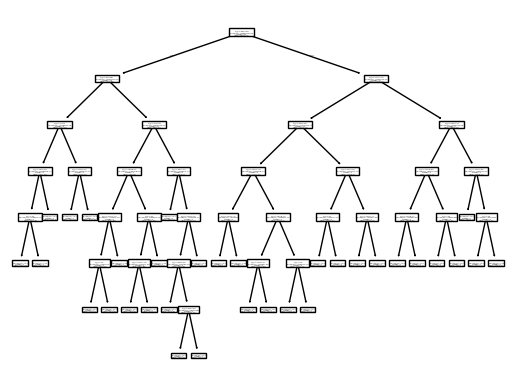

In [47]:
from sklearn import tree
best_tree=grid.best_estimator_
tree.plot_tree(best_tree)
plt.show()

In [49]:
rd_input=float(input("R&D:"))
admin_input=float(input("Admin"))
mark_input=float(input("Marketing "))
fol_input=int(input("State_flo 0 or 1:"))
new_input=int(input("State_new 0 or 1:"))

R&D: 165349.2
Admin 136897.8
Marketing  471784.1
State_flo 0 or 1: 0
State_new 0 or 1: 1


In [53]:
result=grid.predict([[rd_input,admin_input,mark_input,fol_input,new_input]])

C:\Users\alkar\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [55]:
result

array([192261.83])